In [29]:
# Install SSIM package (run once per Kaggle session)
!pip install pytorch-msssim -q

# This Python 3 environment comes with many helpful analytics libraries installed

import numpy as np
import pandas as pd
import os

print("=== Dataset Structure Summary ===")

for dirname, dirnames, filenames in os.walk('/kaggle/input'):

    visible_files = [f for f in filenames if not f.startswith('.')]

    if visible_files:
        print(f"📁 {dirname}")
        print(f"   └── Contains {len(visible_files)} files\n")

=== Dataset Structure Summary ===
📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset
   └── Contains 1 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/368x368
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/92x92
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/368x368
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/92x92
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/720x480
   └── Contains 9500 files



In [33]:
!pip install pytorch-msssim -q

In [34]:
import numpy as np
import pandas as pd
import os
import gc

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image

import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from tqdm import tqdm

# NEW for Stage 4B
from pytorch_msssim import ssim

In [35]:
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Running on:", device)

Running on: cuda


In [36]:
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import torchvision.transforms as transforms

class LunarDataset(Dataset):
    def __init__(self, distorted_dir, clean_dir):
        self.distorted_dir = Path(distorted_dir)
        self.clean_dir = Path(clean_dir)

        self.image_names = sorted([
            img.name
            for img in self.distorted_dir.glob("*")
            if img.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])

        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):

        image_name = self.image_names[idx]

        distorted = Image.open(
            self.distorted_dir / image_name
        ).convert("RGB")

        clean = Image.open(
            self.clean_dir / image_name
        ).convert("RGB")

        distorted = self.transform(distorted)
        clean = self.transform(clean)

        return distorted, clean

In [37]:
distorted_path = "/kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/368x368"

clean_path = "/kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/368x368"

train_dataset = LunarDataset(
    distorted_dir=distorted_path,
    clean_dir=clean_path
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

print("Training Images:", len(train_dataset))

Training Images: 9500


In [38]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):
        return self.conv(x)

In [39]:
class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # ---------------- Encoder ----------------

        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # ---------------- Bottleneck ----------------

        self.middle = DoubleConv(128, 256)

        # ---------------- Decoder ----------------

        self.up1 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.conv1 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.conv2 = DoubleConv(128, 64)

        self.final = nn.Conv2d(
            64,
            3,
            kernel_size=1
        )

    def forward(self, x):

        x1 = self.down1(x)

        x2 = self.down2(
            self.pool1(x1)
        )

        x3 = self.middle(
            self.pool2(x2)
        )

        x = self.up1(x3)

        x = torch.cat(
            [x, x2],
            dim=1
        )

        x = self.conv1(x)

        x = self.up2(x)

        x = torch.cat(
            [x, x1],
            dim=1
        )

        x = self.conv2(x)

        return torch.sigmoid(
            self.final(x)
        )

In [40]:
# ==========================================================
# Stage 4B - U-Net with L1 + SSIM Loss
# Research Hypothesis:
# Combining L1 Loss with SSIM Loss will improve structural
# preservation while maintaining stable optimization.
# ==========================================================

class L1SSIMLoss(nn.Module):

    def __init__(self, w_l1=1.0, w_ssim=1.0):
        super().__init__()

        # Import inside the class to avoid NameError
        from pytorch_msssim import ssim
        self.ssim = ssim

        self.l1 = nn.L1Loss()

        self.w_l1 = w_l1
        self.w_ssim = w_ssim

    def forward(self, prediction, target):

        l1_loss = self.l1(prediction, target)

        ssim_loss = 1.0 - self.ssim(
            prediction,
            target,
            data_range=1.0,
            size_average=True
        )

        total_loss = (
            self.w_l1 * l1_loss +
            self.w_ssim * ssim_loss
        )

        return total_loss, {
            "L1": l1_loss.item(),
            "SSIM": ssim_loss.item()
        }


# ----------------------------------------------------------
# Initialize Model
# ----------------------------------------------------------

model = UNet().to(device)

criterion = L1SSIMLoss(
    w_l1=1.0,
    w_ssim=1.0
)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0005
)

print("=" * 60)
print("Stage 4B Configuration")
print("=" * 60)
print("Model        : U-Net")
print("Loss Function: L1 + SSIM")
print("Optimizer    : Adam")
print("Learning Rate: 0.0005")
print("=" * 60)

print(model)

Stage 4B Configuration
Model        : U-Net
Loss Function: L1 + SSIM
Optimizer    : Adam
Learning Rate: 0.0005
UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (middle): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2):

In [41]:
# Store epoch losses
train_losses = []

epochs = 10

print("\nStarting Stage 4B Training...\n")

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{epochs}"
    )

    for distorted, clean in progress:

        distorted = distorted.to(device)
        clean = clean.to(device)

        prediction = model(distorted)

        loss, parts = criterion(
            prediction,
            clean
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        progress.set_postfix(
            Total=f"{loss.item():.4f}",
            L1=f"{parts['L1']:.4f}",
            SSIM=f"{parts['SSIM']:.4f}"
        )

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Average Loss = {epoch_loss:.5f}"
    )

print("\nStage 4B Training Completed!")
print(f"Final Loss = {train_losses[-1]:.5f}")


Starting Stage 4B Training...



Epoch 1/10: 100%|██████████| 1188/1188 [13:11<00:00,  1.50it/s, L1=0.0414, SSIM=0.4629, Total=0.5042]


Epoch [1/10] Average Loss = 0.54689


Epoch 2/10: 100%|██████████| 1188/1188 [13:02<00:00,  1.52it/s, L1=0.0422, SSIM=0.4061, Total=0.4482]


Epoch [2/10] Average Loss = 0.52934


...

Epoch [8/10] Average Loss = 0.48612


Epoch 9/10: 100%|██████████| 1188/1188 [12:58<00:00,  1.53it/s, L1=0.0477, SSIM=0.4342, Total=0.4820]


Epoch [9/10] Average Loss = 0.48423


Epoch 10/10: 100%|██████████| 1188/1188 [12:57<00:00,  1.53it/s, L1=0.0425, SSIM=0.4445, Total=0.4870]

Epoch [10/10] Average Loss = 0.48249

Stage 4B Training Completed!
Final Loss = 0.48249


In [42]:
torch.save(
    model.state_dict(),
    "lunavision_stage4B_l1_ssim.pth"
)

print("=" * 60)
print("Stage 4B model saved successfully!")
print("=" * 60)

Stage 4B model saved successfully!


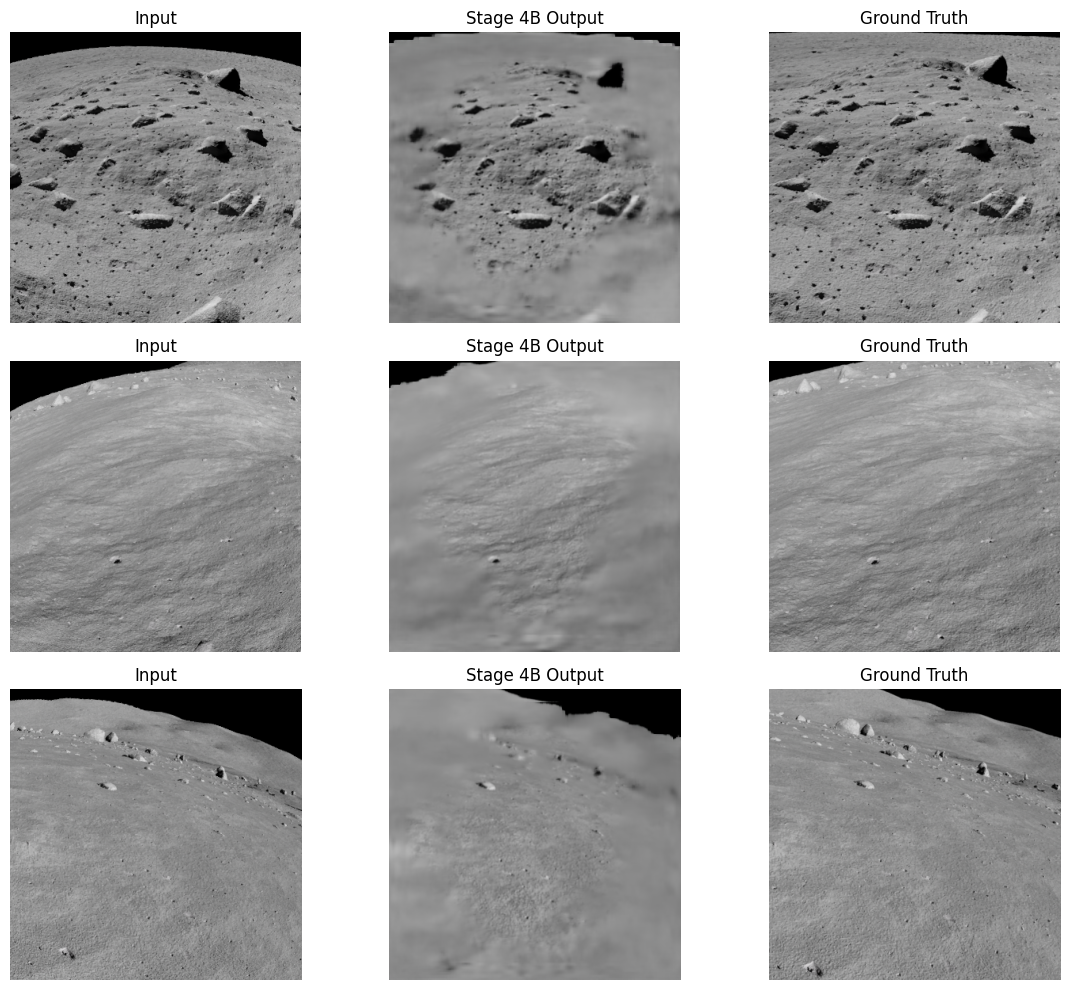

In [43]:
model.eval()

distorted_batch, clean_batch = next(iter(train_loader))

with torch.no_grad():

    prediction = model(
        distorted_batch.to(device)
    ).cpu()

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12,10)
)

for i in range(3):

    # Distorted Image
    axes[i,0].imshow(
        distorted_batch[i].permute(1,2,0)
    )
    axes[i,0].set_title("Input")
    axes[i,0].axis("off")

    # Restored Image
    axes[i,1].imshow(
        prediction[i].permute(1,2,0)
    )
    axes[i,1].set_title("Stage 4B Output")
    axes[i,1].axis("off")

    # Ground Truth
    axes[i,2].imshow(
        clean_batch[i].permute(1,2,0)
    )
    axes[i,2].set_title("Ground Truth")
    axes[i,2].axis("off")

plt.tight_layout()
plt.show()

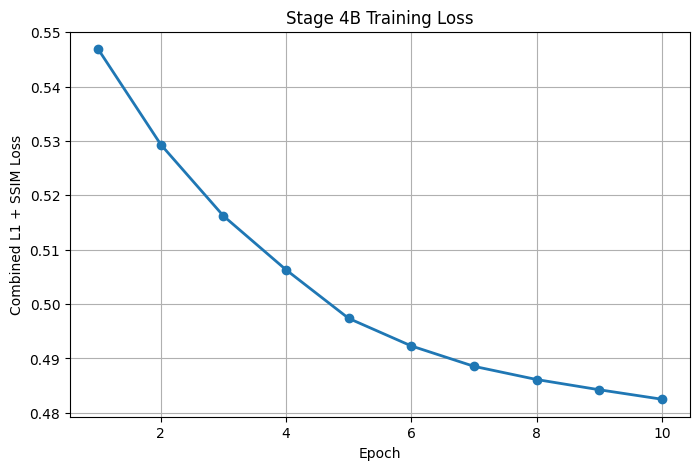

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, epochs+1),
    train_losses,
    marker='o',
    linewidth=2
)

plt.title("Stage 4B Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Combined L1 + SSIM Loss")

plt.grid(True)

plt.show()